# APRENDIZAJE AUTOMÁTICO
# Práctica 3: Regresión Logística Binaria
### Autor: Sanchez Sarsa, Eduardo
### NIP:   901813
### Fecha: 20-02-2026
---


## Configuración


In [1]:
%matplotlib inline
# try:
#   from google.colab import drive
#   print("Trabajando en Colab")
#   drive.mount('/content/drive')                # Monta tu google drive
#   Path = '/content/drive/MyDrive/Aprendizaje/' # Directorio donde guardas los ficheros
# except:
print("Trabajando en local")
import os
Path = os.getcwd() + "/"  # Directorio donde guardas los ficheros


Trabajando en local


---
## 0. Visualización de datos


Train: 142 muestras | positivos=45 (0.317)
Test : 36 muestras | positivos=14 (0.389)


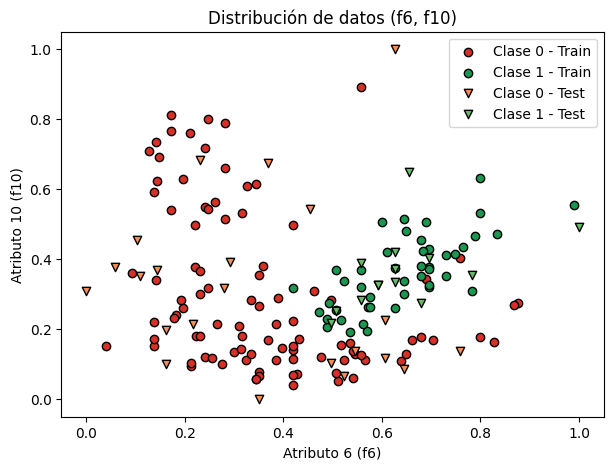

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.exceptions import ConvergenceWarning
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

warnings.filterwarnings("ignore", category=ConvergenceWarning)
SEED = 28


# Dibuja la frontera y los puntos de train/test para clasificadores binarios con 2 atributos.
def dibujar_clasificador(clf, X_train, y_train, X_test, y_test, titulo):
    colores = ListedColormap(["#d73027", "#1a9850"])
    fig, ax = plt.subplots(figsize=(7, 5))
    DecisionBoundaryDisplay.from_estimator(
        clf,
        X_train,
        eps=0.15,
        cmap=colores,
        grid_resolution=400,
        response_method="predict",
        alpha=0.30,
        ax=ax,
    )
    ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c="#d73027", edgecolors="k", label="0 - Train")
    ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c="#1a9850", edgecolors="k", label="1 - Train")
    ax.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], c="#d73027", marker="v", edgecolors="k", label="0 - Test")
    ax.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], c="#1a9850", marker="v", edgecolors="k", label="1 - Test")
    ax.set_xlabel("Atributo 6 (f6)")
    ax.set_ylabel("Atributo 10 (f10)")
    ax.set_title(titulo)
    ax.legend(loc="best")
    plt.show()


# Leer los ficheros de datos y pasarlos a matrices de numpy.
data_train = pd.read_csv(Path + "wine_train.csv", sep=";")
data_test = pd.read_csv(Path + "wine_test.csv", sep=";")

X_train = data_train[["f6", "f10"]].to_numpy()
X_test = data_test[["f6", "f10"]].to_numpy()
y_train = (data_train["Clase"].to_numpy() == 1).astype(int)
y_test = (data_test["Clase"].to_numpy() == 1).astype(int)

print(f"Train: {X_train.shape[0]} muestras | positivos={y_train.sum()} ({y_train.mean():.3f})")
print(f"Test : {X_test.shape[0]} muestras | positivos={y_test.sum()} ({y_test.mean():.3f})")

plt.figure(figsize=(7, 5))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c="#d73027", edgecolors="k", label="Clase 0 - Train")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c="#1a9850", edgecolors="k", label="Clase 1 - Train")
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], c="#fc8d59", marker="v", edgecolors="k", label="Clase 0 - Test")
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], c="#66bd63", marker="v", edgecolors="k", label="Clase 1 - Test")
plt.title("Distribución de datos (f6, f10)")
plt.xlabel("Atributo 6 (f6)")
plt.ylabel("Atributo 10 (f10)")
plt.legend(loc="best")
plt.show()


Los datos están normalizados y hay cierto desbalance de clase (la clase 1 es minoritaria en entrenamiento), por lo que no conviene fijarse solo en `accuracy`. Además, en el plano `(f6, f10)` se aprecia solapamiento entre clases, lo que hace útil comparar un modelo lineal frente a uno no lineal y regularizado.


---
## 1. Métricas

Para este problema de detección de clase 1, son especialmente relevantes:

- `precision`: evita falsos positivos si queremos que las predicciones de clase 1 sean fiables.
- `recall`: mide cuántos vinos de clase 1 conseguimos detectar.
- `F1`: equilibrio entre `precision` y `recall`.
- `average precision (AP)` y curvas `precision/recall`: útiles con clases desbalanceadas y para comparar umbrales.
- `ROC-AUC`: complementa la evaluación basada en ranking de probabilidades.

Se mantiene `accuracy` como referencia, pero no como métrica principal.


In [3]:
def metricas_binarias(y_true, y_pred, y_prob):
    metricas = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    if len(np.unique(y_true)) == 2:
        metricas["roc_auc"] = roc_auc_score(y_true, y_prob)
        metricas["average_precision"] = average_precision_score(y_true, y_prob)
    else:
        metricas["roc_auc"] = np.nan
        metricas["average_precision"] = np.nan

    return metricas


def evaluar_modelo(modelo, nombre, X_train, y_train, X_test, y_test, umbral=0.5):
    filas = []

    for split, X, y in [("train", X_train, y_train), ("test", X_test, y_test)]:
        y_prob = modelo.predict_proba(X)[:, 1]
        y_pred = (y_prob >= umbral).astype(int)
        m = metricas_binarias(y, y_pred, y_prob)
        tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0, 1]).ravel()
        m.update({
            "modelo": nombre,
            "split": split,
            "umbral": umbral,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
        })
        filas.append(m)

    columnas = [
        "modelo", "split", "umbral", "accuracy", "precision", "recall", "f1",
        "average_precision", "roc_auc", "tn", "fp", "fn", "tp"
    ]
    return pd.DataFrame(filas)[columnas]


def dibujar_roc_train_test(modelo, nombre, X_train, y_train, X_test, y_test):
    fig, ax = plt.subplots(figsize=(7, 5))

    for split, X, y in [("train", X_train, y_train), ("test", X_test, y_test)]:
        y_prob = modelo.predict_proba(X)[:, 1]
        fpr, tpr, _ = roc_curve(y, y_prob)
        auc = roc_auc_score(y, y_prob)
        ax.plot(fpr, tpr, linewidth=2, label=f"{split} | AUC={auc:.3f}")

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Tasa de Falsos Positivos")
    ax.set_ylabel("Tasa de Verdaderos Positivos")
    ax.set_title(f"ROC - {nombre}")
    ax.grid(alpha=0.25)
    ax.legend(loc="lower right")
    plt.show()


print("Métrica principal para selección: average_precision (AP)")
print(f"Prevalencia de clase 1 en train: {y_train.mean():.3f}")
print(f"Prevalencia de clase 1 en test : {y_test.mean():.3f}")


Métrica principal para selección: average_precision (AP)
Prevalencia de clase 1 en train: 0.317
Prevalencia de clase 1 en test : 0.389


---
## 2. Regresión logística básica
### a) Entrenamiento, superficie de separación y evaluación


c:\Users\eduar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,modelo,split,umbral,accuracy,precision,recall,f1,average_precision,roc_auc,tn,fp,fn,tp
0,Logística básica,train,0.5,0.809859,0.736842,0.622222,0.674699,0.744974,0.906987,87,10,17,28
1,Logística básica,test,0.5,0.861111,0.846154,0.785714,0.814815,0.771994,0.883117,20,2,3,11


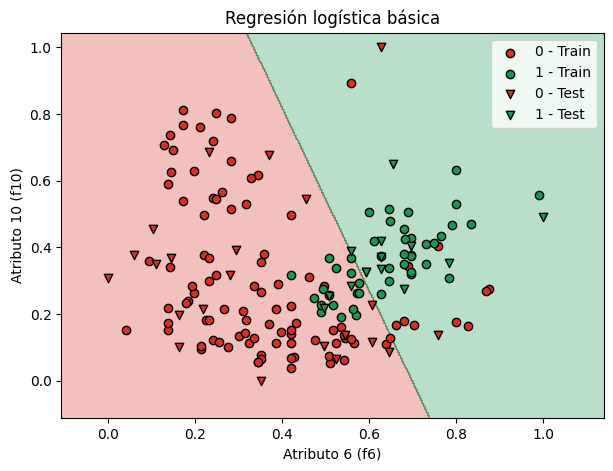

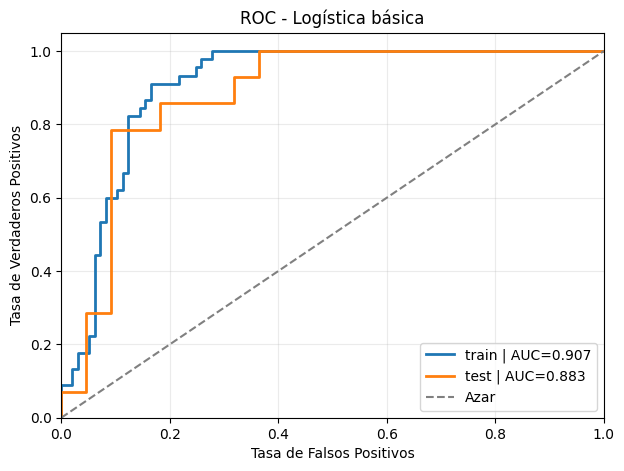

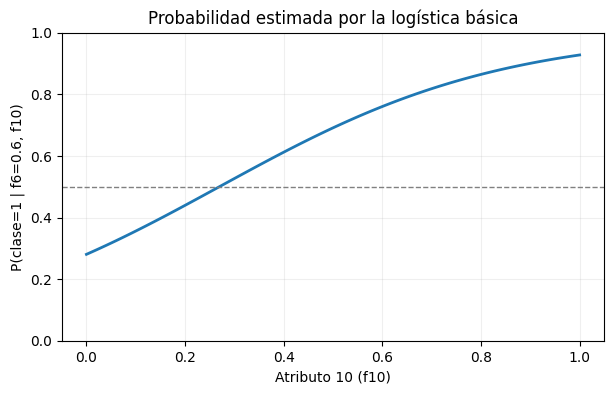

Coeficientes: w_f6=9.5750, w_f10=3.4955, b=-6.6871
Para f6=0.6, el punto con P=0.5 ocurre en f10≈0.2695


In [4]:
logit_basico = LogisticRegression(penalty=None)
logit_basico.fit(X_train, y_train)

metricas_basico = evaluar_modelo(
    logit_basico,
    "Logística básica",
    X_train,
    y_train,
    X_test,
    y_test,
    umbral=0.5,
)

display(metricas_basico)
dibujar_clasificador(logit_basico, X_train, y_train, X_test, y_test, "Regresión logística básica")

dibujar_roc_train_test(logit_basico, "Logística básica", X_train, y_train, X_test, y_test)


# Probabilidad para f6=0.6 y f10 entre 0 y 1.
f10_grid = np.linspace(0.0, 1.0, 100)
X_consulta = np.c_[np.full_like(f10_grid, 0.6), f10_grid]
prob_clase1 = logit_basico.predict_proba(X_consulta)[:, 1]

plt.figure(figsize=(7, 4))
plt.plot(f10_grid, prob_clase1, color="#1f78b4", linewidth=2)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Atributo 10 (f10)")
plt.ylabel("P(clase=1 | f6=0.6, f10)")
plt.title("Probabilidad estimada por la logística básica")
plt.ylim(0, 1)
plt.grid(alpha=0.2)
plt.show()

w_f6, w_f10 = logit_basico.coef_[0]
b = logit_basico.intercept_[0]
print(f"Coeficientes: w_f6={w_f6:.4f}, w_f10={w_f10:.4f}, b={b:.4f}")

if abs(w_f10) > 1e-12:
    f10_corte = -(b + w_f6 * 0.6) / w_f10
    print(f"Para f6=0.6, el punto con P=0.5 ocurre en f10≈{f10_corte:.4f}")
else:
    print("w_f10≈0: la probabilidad casi no depende de f10")


### Interpretación

La gráfica de probabilidad en función de `f10` (con `f6` fijo) tiene forma sigmoide. La razón es que la regresión logística aplica la función logística a un predictor lineal:

`P(y=1|x) = sigma(w0 + w1*f6 + w2*f10)`.

Al fijar `f6=0.6`, la expresión interna queda lineal en `f10`; al pasarla por `sigma`, aparece la curva en S.


### Interpretación

La gráfica de probabilidad en función de `f10` (con `f6` fijo) tiene forma sigmoide. La razón es que la regresión logística aplica la función logística a un predictor lineal:

`P(y=1|x) = sigma(w0 + w1*f6 + w2*f10)`.

Al fijar `f6=0.6`, la expresión interna queda lineal en `f10`; al pasarla por `sigma`, aparece la curva en S.


---
## 3. Expansión polinómica (grado 6) sin regularizar


c:\Users\eduar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\eduar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\eduar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\eduar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\eduar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_rati

,solver,ap_train_media,ap_val_media,ap_val_std,f1_train,f1_val
1,newton-cg,0.973534,0.893418,0.115698,0.940533,0.926013
0,lbfgs,0.971546,0.890076,0.111904,0.937722,0.912778
2,saga,0.956320,0.934745,0.052641,0.923129,0.877807


Solver seleccionado para el modelo sin regularizar: newton-cg (CV F1=0.9260)


,modelo,split,umbral,accuracy,precision,recall,f1,average_precision,roc_auc,tn,fp,fn,tp
0,Polinómica g6 sin regularizar (newton-cg),train,0.5,0.964789,0.916667,0.977778,0.946237,0.974542,0.989920,93,4,1,44
1,Polinómica g6 sin regularizar (newton-cg),test,0.5,0.944444,0.875000,1.000000,0.933333,0.960886,0.977273,20,2,0,14


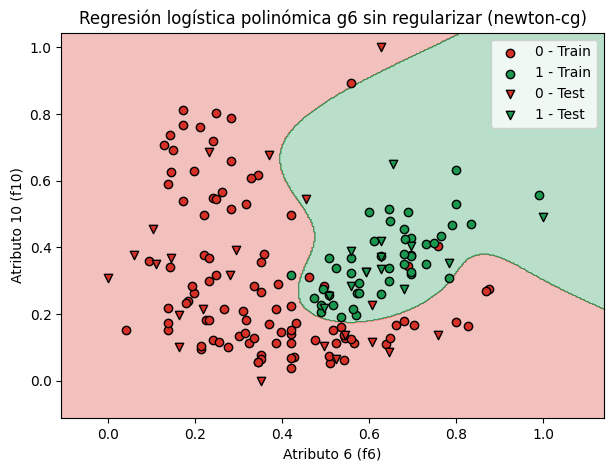

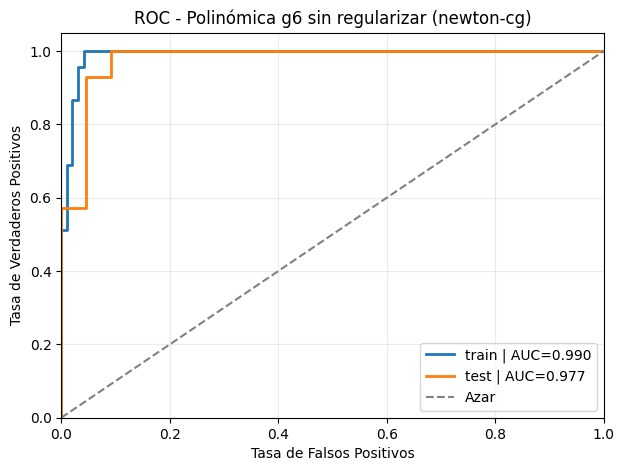

In [27]:
solvers_sin_reg = ["lbfgs", "newton-cg", "saga"]
# skf_sin_reg = KFold(n_splits=5, shuffle=True, random_state=28)

grid_sin_reg = GridSearchCV(
    estimator=Pipeline(
        [
            ("poly", PolynomialFeatures(degree=6)),
            ("logreg", LogisticRegression(C=np.inf, max_iter=50000, random_state=28)),
        ]
    ),
    param_grid={"logreg__solver": solvers_sin_reg},
    scoring={"ap": "average_precision", "f1": "f1"},
    # cv=skf_sin_reg,
    refit="f1",
    return_train_score=True,
    error_score=np.nan,
)

grid_sin_reg.fit(X_train, y_train)

cv_results_sin_reg = grid_sin_reg.cv_results_
df_sin_reg = pd.DataFrame(
    {
        "solver": np.array(cv_results_sin_reg["param_logreg__solver"], dtype=str),
        "ap_train_media": cv_results_sin_reg["mean_train_ap"],
        "ap_val_media": cv_results_sin_reg["mean_test_ap"],
        "ap_val_std": cv_results_sin_reg["std_test_ap"],
        "f1_train": cv_results_sin_reg["mean_train_f1"],
        "f1_val": cv_results_sin_reg["mean_test_f1"],
    }
).sort_values(by="f1_val", ascending=False)

df_sin_reg = df_sin_reg.dropna(subset=["f1_val"])
if df_sin_reg.empty:
    raise RuntimeError("No se pudo entrenar ningún modelo polinómico sin regularizar")

display(df_sin_reg)

mejor_solver_sin_reg = grid_sin_reg.best_params_["logreg__solver"]
modelo_poly_sin_reg = grid_sin_reg.best_estimator_

print(
    f"Solver seleccionado para el modelo sin regularizar: {mejor_solver_sin_reg} "
    f"(CV F1={grid_sin_reg.best_score_:.4f})"
)

metricas_sin_reg = evaluar_modelo(
    modelo_poly_sin_reg,
    f"Polinómica g6 sin regularizar ({mejor_solver_sin_reg})",
    X_train,
    y_train,
    X_test,
    y_test,
    umbral=0.5,
)
display(metricas_sin_reg)

dibujar_clasificador(
    modelo_poly_sin_reg,
    X_train,
    y_train,
    X_test,
    y_test,
    f"Regresión logística polinómica g6 sin regularizar ({mejor_solver_sin_reg})",
)

dibujar_roc_train_test(
    modelo_poly_sin_reg,
    f"Polinómica g6 sin regularizar ({mejor_solver_sin_reg})",
    X_train,
    y_train,
    X_test,
    y_test,
)


---
## 4. Regularización (grado 6) y selección de `C` con k-fold

Se usa validación cruzada estratificada (`k=5`) y métrica de selección `average_precision`.


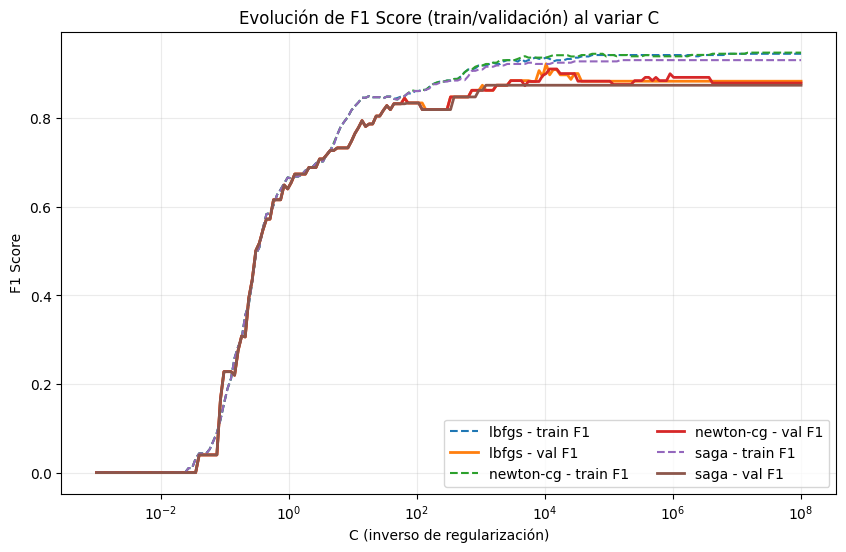

Mejor combinación por CV: solver=lbfgs, C=10473.7, val_F1=0.9229


,modelo,split,umbral,accuracy,precision,recall,f1,average_precision,roc_auc,tn,fp,fn,tp
0,"Polinómica g6 regularizada (lbfgs, C=1.047e+04)",train,0.5,0.957746,0.914894,0.955556,0.934783,0.967481,0.986712,93,4,2,43
1,"Polinómica g6 regularizada (lbfgs, C=1.047e+04)",test,0.5,0.944444,0.928571,0.928571,0.928571,0.984642,0.990260,21,1,1,13


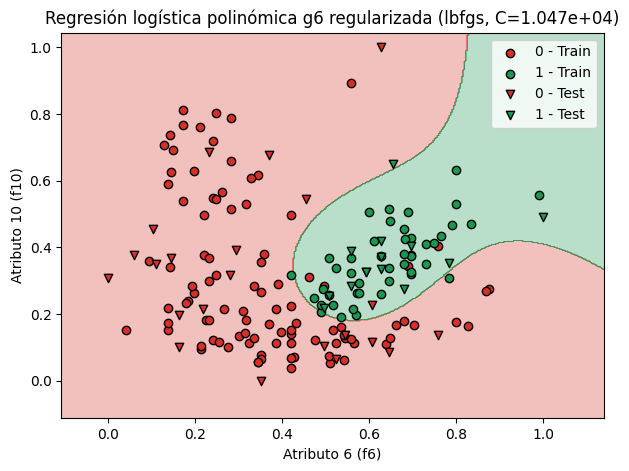

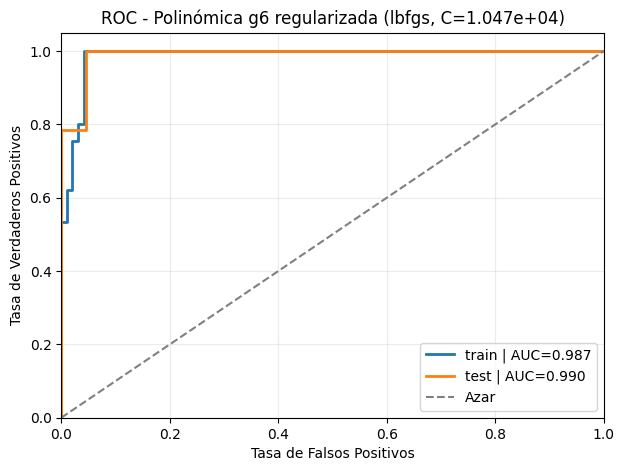

In [40]:
Cs = np.logspace(-3, 8, 200)
solvers_reg = ["lbfgs", "newton-cg", "saga"]
cv = KFold(n_splits=5, shuffle=True, random_state=28)

grid_reg = GridSearchCV(
    estimator=Pipeline(
        [
            ("poly", PolynomialFeatures(degree=6, include_bias=False)),
            ("logreg", LogisticRegression(max_iter=50000, random_state=28)),
        ]
    ),
    param_grid={"logreg__solver": solvers_reg, "logreg__C": Cs},
    scoring="f1",
    cv=cv,
    return_train_score=True,
    error_score=np.nan,
)

grid_reg.fit(X_train, y_train)

cv_results = grid_reg.cv_results_
df_cv = pd.DataFrame(
    {
        "solver": np.array(cv_results["param_logreg__solver"], dtype=str),
        "C": np.array(cv_results["param_logreg__C"], dtype=float),
        "train_f1": cv_results["mean_train_score"],
        "val_f1": cv_results["mean_test_score"],
        "val_f1_std": cv_results["std_test_score"],
    }
)

df_cv_ok = df_cv.dropna(subset=["val_f1"]).copy()
if df_cv_ok.empty:
    raise RuntimeError("No se pudo completar la validación cruzada para ningún solver")

plt.figure(figsize=(10, 6))
for solver in solvers_reg:
    d = df_cv_ok[df_cv_ok["solver"] == solver].sort_values("C")
    if d.empty:
        continue
    plt.semilogx(d["C"], d["train_f1"], linestyle="--", linewidth=1.5, label=f"{solver} - train F1")
    plt.semilogx(d["C"], d["val_f1"], linestyle="-", linewidth=2.0, label=f"{solver} - val F1")

plt.xlabel("C (inverso de regularización)")
plt.ylabel("F1 Score")
plt.title("Evolución de F1 Score (train/validación) al variar C")
plt.grid(alpha=0.25)
plt.legend(loc="best", ncol=2)
plt.show()

mejor_solver_reg = grid_reg.best_params_["logreg__solver"]
mejor_C = float(grid_reg.best_params_["logreg__C"])

print(f"Mejor combinación por CV: solver={mejor_solver_reg}, C={mejor_C:.6g}, val_F1={grid_reg.best_score_:.4f}")

# GridSearchCV ya reentrena con la mejor combinación usando todo el train.
modelo_poly_reg = grid_reg.best_estimator_

metricas_reg = evaluar_modelo(
    modelo_poly_reg,
    f"Polinómica g6 regularizada ({mejor_solver_reg}, C={mejor_C:.4g})",
    X_train,
    y_train,
    X_test,
    y_test,
    umbral=0.5,
)
display(metricas_reg)

dibujar_clasificador(
    modelo_poly_reg,
    X_train,
    y_train,
    X_test,
    y_test,
    f"Regresión logística polinómica g6 regularizada ({mejor_solver_reg}, C={mejor_C:.4g})",
)

dibujar_roc_train_test(
    modelo_poly_reg,
    f"Polinómica g6 regularizada ({mejor_solver_reg}, C={mejor_C:.4g})",
    X_train,
    y_train,
    X_test,
    y_test,
)


In [43]:
# Extraemos los coeficientes (pesos) del modelo SIN regularizar
pesos_sin_reg = modelo_poly_sin_reg.named_steps['logreg'].coef_[0]

# Extraemos los coeficientes (pesos) del modelo CON regularizar (asumiendo que se llama así)
pesos_reg = modelo_poly_reg.named_steps['logreg'].coef_[0]

print("--- ANÁLISIS DE SOBREAJUSTE (PESOS) ---")
print(f"SIN regularizar -> Peso máximo absoluto: {np.max(np.abs(pesos_sin_reg)):.2f}")
print(f"SIN regularizar -> Media de los pesos:   {np.mean(np.abs(pesos_sin_reg)):.2f}\n")

print(f"CON regularizar -> Peso máximo absoluto: {np.max(np.abs(pesos_reg)):.2f}")
print(f"CON regularizar -> Media de los pesos:   {np.mean(np.abs(pesos_reg)):.2f}")

--- ANÁLISIS DE SOBREAJUSTE (PESOS) ---
SIN regularizar -> Peso máximo absoluto: 680.70
SIN regularizar -> Media de los pesos:   210.13

CON regularizar -> Peso máximo absoluto: 82.81
CON regularizar -> Media de los pesos:   22.77


---
## 5. Curvas Precisión/Recall y ROC
### a) Comparación en test


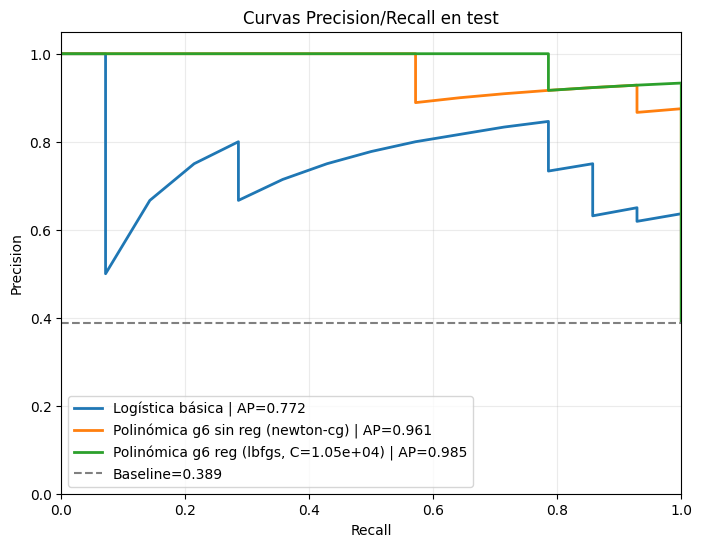

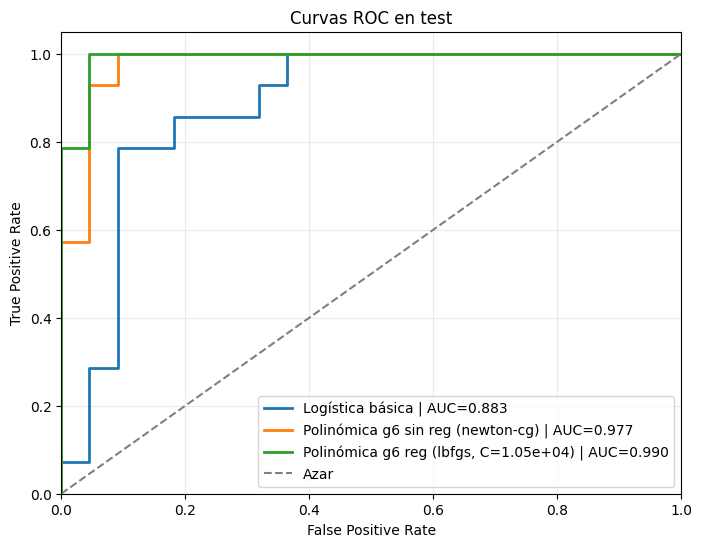

In [41]:
modelos = {
    "Logística básica": logit_basico,
    f"Polinómica g6 sin reg ({mejor_solver_sin_reg})": modelo_poly_sin_reg,
    f"Polinómica g6 reg ({mejor_solver_reg}, C={mejor_C:.3g})": modelo_poly_reg,
}

probs_test = {nombre: modelo.predict_proba(X_test)[:, 1] for nombre, modelo in modelos.items()}

# Curvas Precision/Recall en una figura conjunta.
plt.figure(figsize=(8, 6))
for nombre, prob in probs_test.items():
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(recall, precision, linewidth=2, label=f"{nombre} | AP={ap:.3f}")

baseline = y_test.mean()
plt.hlines(baseline, 0, 1, colors="gray", linestyles="--", label=f"Baseline={baseline:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas Precision/Recall en test")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)
plt.legend(loc="best")
plt.show()


# Curvas ROC en una figura conjunta (todos los modelos).
fig, ax = plt.subplots(figsize=(8, 6))
for nombre, prob in probs_test.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, linewidth=2, label=f"{nombre} | AUC={auc:.3f}")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curvas ROC en test")
ax.grid(alpha=0.25)
ax.legend(loc="lower right")
plt.show()

In [42]:
# b) Ajuste de umbral para garantizar precision >= 0.90.
def umbral_para_precision_objetivo(y_true, y_prob, precision_objetivo=0.90):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

    # precision/recall tienen un punto más que thresholds.
    precision_t = precision[:-1]
    recall_t = recall[:-1]

    factibles = np.where(precision_t >= precision_objetivo)[0]
    if factibles.size == 0:
        return None

    # Entre los factibles, elegimos el de mayor recall.
    mejor = factibles[np.argmax(recall_t[factibles])]
    return {
        "threshold": float(thresholds[mejor]),
        "precision": float(precision_t[mejor]),
        "recall": float(recall_t[mejor]),
    }


precision_objetivo = 0.90
registros_umbral = []

for nombre, prob in probs_test.items():
    ajuste = umbral_para_precision_objetivo(y_test, prob, precision_objetivo=precision_objetivo)
    if ajuste is None:
        registros_umbral.append(
            {
                "modelo": nombre,
                "factible": False,
                "threshold": np.nan,
                "precision": np.nan,
                "recall": np.nan,
                "f1": np.nan,
                "predichos_clase1": 0,
            }
        )
        continue

    y_pred = (prob >= ajuste["threshold"]).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    registros_umbral.append(
        {
            "modelo": nombre,
            "factible": True,
            "threshold": ajuste["threshold"],
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "predichos_clase1": int(y_pred.sum()),
            "tn": int(cm[0,0]),
            "fp": int(cm[0,1]),
            "fn": int(cm[1,0]),
            "tp": int(cm[1,1]),
        }
    )


df_umbral = pd.DataFrame(registros_umbral).sort_values(by=["factible", "recall"], ascending=[False, False])
display(df_umbral)


,modelo,factible,threshold,precision,recall,f1,predichos_clase1,tn,fp,fn,tp
2,"Polinómica g6 reg (lbfgs, C=1.05e+04)",True,0.346391,0.933333,1.000000,0.965517,15,21,1,0,14
1,Polinómica g6 sin reg (newton-cg),True,0.824892,0.928571,0.928571,0.928571,14,21,1,1,13
0,Logística básica,True,0.990135,1.000000,0.071429,0.133333,1,22,0,13,1
